In [1]:
import pandas as pd
import os


In [18]:
df = pd.read_csv(
    "gene_counts.txt",
    sep="\t",
    skiprows=1   # Skip featureCounts metadata line
)
df.head()

,Geneid,Chr,Start,End,Strand,Length,/home/godfather/Downloads/Unix/rnaseq_project/results/SRR18297038_1.sorted.bam,/home/godfather/Downloads/Unix/rnaseq_project/results/SRR18297042_1.sorted.bam
0,AT1G30814,1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;...,10942648;10942648;10942648;10942663;10943007;1...,10942909;10942909;10942909;10942909;10943060;1...,-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;...,1657,12,2
1,AT1G78930,1;1;1;1;1;1;1,29677904;29678707;29679017;29679327;29679538;2...,29678618;29678924;29679199;29679440;29679783;2...,-;-;-;-;-;-;-,2266,56,39
2,AT1G71695,1;1;1,26964087;26965591;26965943,26964625;26965785;26966688,+;+;+,1480,1300,1359
3,AT1G58983,1;1,21805932;21806783,21806440;21807496,-;-,1223,1,0
4,AT1G12980,1,4429718,4430965,+,1248,8,3


In [19]:
df.columns

Index(['Geneid', 'Chr', 'Start', 'End', 'Strand', 'Length',
       '/home/godfather/Downloads/Unix/rnaseq_project/results/SRR18297038_1.sorted.bam',
       '/home/godfather/Downloads/Unix/rnaseq_project/results/SRR18297042_1.sorted.bam'],
      dtype='object')

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 8 columns):
 #   Column                                                                          Non-Null Count  Dtype 
---  ------                                                                          --------------  ----- 
 0   Geneid                                                                          32833 non-null  object
 1   Chr                                                                             32833 non-null  object
 2   Start                                                                           32833 non-null  object
 3   End                                                                             32833 non-null  object
 4   Strand                                                                          32833 non-null  object
 5   Length                                                                          32833 non-null  int64 
 6   /home/godfather/Downloa

In [22]:
new_df = df[['Geneid', '/home/godfather/Downloads/Unix/rnaseq_project/results/SRR18297038_1.sorted.bam','/home/godfather/Downloads/Unix/rnaseq_project/results/SRR18297042_1.sorted.bam']]

In [23]:
new_df.head()

,Geneid,/home/godfather/Downloads/Unix/rnaseq_project/results/SRR18297038_1.sorted.bam,/home/godfather/Downloads/Unix/rnaseq_project/results/SRR18297042_1.sorted.bam
0,AT1G30814,12,2
1,AT1G78930,56,39
2,AT1G71695,1300,1359
3,AT1G58983,1,0
4,AT1G12980,8,3


In [24]:
#Column Renaming

new_df.rename(columns={
    '/home/godfather/Downloads/Unix/rnaseq_project/results/SRR18297038_1.sorted.bam': 'WT',
    '/home/godfather/Downloads/Unix/rnaseq_project/results/SRR18297042_1.sorted.bam': 'H2B8'
}, inplace=True)

C:\Users\rahul\AppData\Local\Temp\ipykernel_23596\3113318193.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df.rename(columns={


In [25]:
new_df.head()

,Geneid,WT,H2B8
0,AT1G30814,12,2
1,AT1G78930,56,39
2,AT1G71695,1300,1359
3,AT1G58983,1,0
4,AT1G12980,8,3


In [26]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Geneid  32833 non-null  object
 1   WT      32833 non-null  int64 
 2   H2B8    32833 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 769.7+ KB


,Geneid,WT,H2B8
2,AT1G71695,1300,1359
9,AT1G72450,1515,873
21,AT1G26670,1410,783
31,AT1G80870,1157,432
32,AT1G75310,2462,907
...,...,...,...
32786,ATCG00420,67610,34890
32795,ATCG00290,1574,3020
32798,ATCG00030,13375,8506
32803,ATCG00450,17206,22770


In [29]:
import numpy as np

# Avoid division by zero
new_df['log2FC'] = np.log2((new_df['H2B8'] + 1) / (new_df['WT'] + 1))

# Genes higher in H2B8
upregulated = new_df[new_df['log2FC'] > 1]

# Sort strongest first
upregulated = upregulated.sort_values(
    by='log2FC',
    ascending=False
)

print(upregulated.head(20))

          Geneid  WT   H2B8     log2FC
1529   AT1G08170   8  63077  12.774924
30333  AT4G33720   0     89   6.491853
6624   AT1G69920   0     39   5.321928
27580  AT2G01010   7    311   5.285402
7030   AT1G15580   0     28   4.857981
5333   AT1G61800   0     27   4.807355
486    AT1G56240   0     26   4.754888
9294   AT5G67080   0     26   4.754888
3295   AT1G27570   5    150   4.653442
23737  AT2G14560   0     24   4.643856
1588   AT1G69930   0     22   4.523562
12034  AT5G65600   0     19   4.321928
23979  AT2G33780   0     18   4.247928
7242   AT1G06097   0     17   4.169925
20039  AT3G57360   0     16   4.087463
11584  AT5G22530   0     16   4.087463
23618  AT2G04495   0     15   4.000000
4520   AT1G59124   8    140   3.969626
8912   AT5G57650   0     14   3.906891
850    AT1G51780   0     14   3.906891


C:\Users\rahul\AppData\Local\Temp\ipykernel_23596\1627860016.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['log2FC'] = np.log2((new_df['H2B8'] + 1) / (new_df['WT'] + 1))


In [31]:
filtered = new_df[
    (new_df['WT'] + new_df['H2B8']) >= 20
].copy()

filtered['log2FC'] = np.log2(
    (filtered['H2B8']+1) /
    (filtered['WT']+1)
)

upregulated = filtered[
    filtered['log2FC'] > 1
].sort_values(
    'log2FC',
    ascending=False
)

print(upregulated.head())

          Geneid  WT   H2B8     log2FC
1529   AT1G08170   8  63077  12.774924
30333  AT4G33720   0     89   6.491853
6624   AT1G69920   0     39   5.321928
27580  AT2G01010   7    311   5.285402
7030   AT1G15580   0     28   4.857981


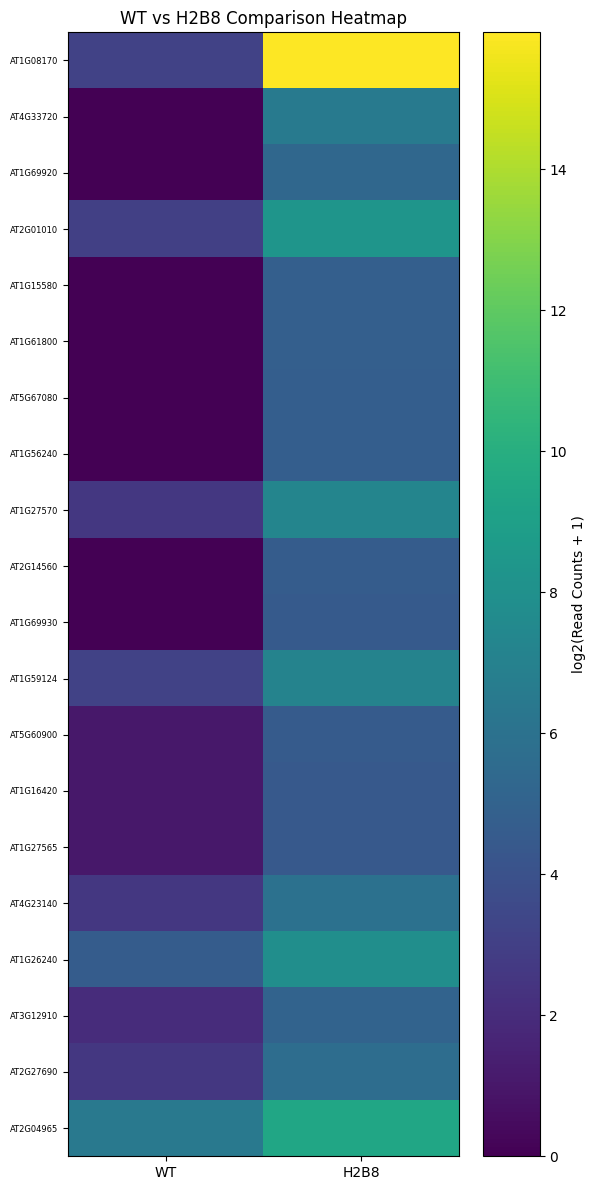

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# Select top upregulated genes
top = (
    upregulated
    .sort_values('log2FC', ascending=False)
    .head(20)
)

# Build matrix
heat = top.set_index('Geneid')[['WT', 'H2B8']]

# Log transform counts
heat_log = np.log2(heat + 1)

plt.figure(figsize=(6,12))

plt.imshow(
    heat_log.values,
    aspect='auto'
)

plt.xticks(
    np.arange(len(heat_log.columns)),
    heat_log.columns
)

plt.yticks(
    np.arange(len(heat_log.index)),
    heat_log.index,
    fontsize=6
)

plt.colorbar(label='log2(Read Counts + 1)')

plt.title('WT vs H2B8 Comparison Heatmap')

plt.tight_layout()
plt.show()


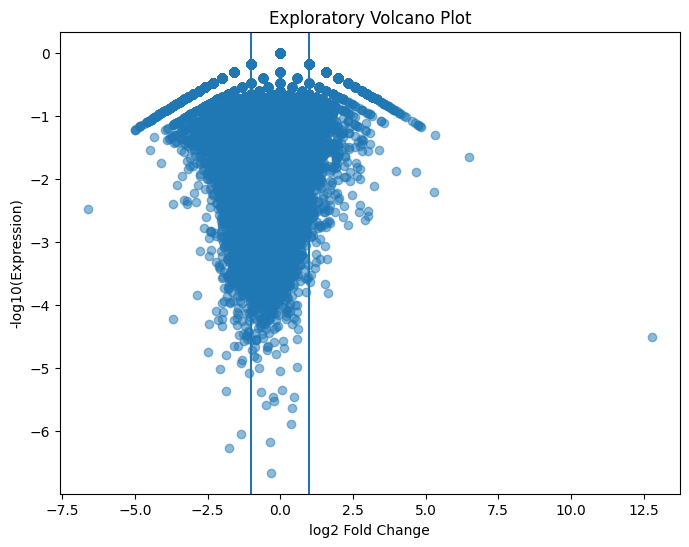

In [37]:
volcano = new_df.copy()

# Log2 Fold Change
volcano['log2FC'] = np.log2(
    (volcano['H2B8'] + 1) /
    (volcano['WT'] + 1)
)

# Fake significance proxy
volcano['mean_expr'] = (
    volcano['WT'] +
    volcano['H2B8']
) / 2

volcano['pseudo_p'] = -np.log10(
    volcano['mean_expr'] + 1
)

plt.figure(figsize=(8,6))

plt.scatter(
    volcano['log2FC'],
    volcano['pseudo_p'],
    alpha=0.5
)

plt.axvline(1)
plt.axvline(-1)

plt.xlabel('log2 Fold Change')
plt.ylabel('-log10(Expression)')
plt.title('Exploratory Volcano Plot')

plt.show()

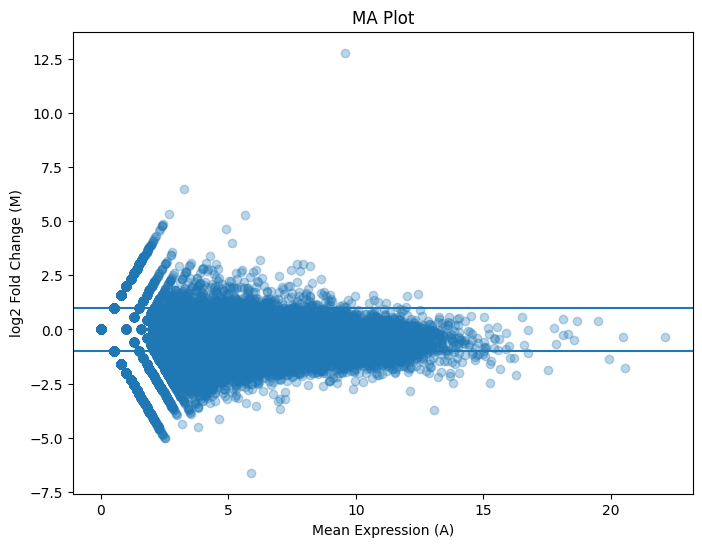

In [38]:
ma = new_df.copy()

# M
ma['M'] = np.log2(
    (ma['H2B8'] + 1) /
    (ma['WT'] + 1)
)

# A
ma['A'] = (
    np.log2(ma['WT'] + 1) +
    np.log2(ma['H2B8'] + 1)
) / 2

plt.figure(figsize=(8,6))

plt.scatter(
    ma['A'],
    ma['M'],
    alpha=0.3
)

plt.axhline(1)
plt.axhline(-1)

plt.xlabel('Mean Expression (A)')
plt.ylabel('log2 Fold Change (M)')

plt.title('MA Plot')

plt.show()